# Dados


In [119]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import LinearRegression

In [32]:
np.random.seed(42)

m = 1000
X = np.random.rand(m,1)
y = 2 * X + 4 + np.random.rand(m,1)

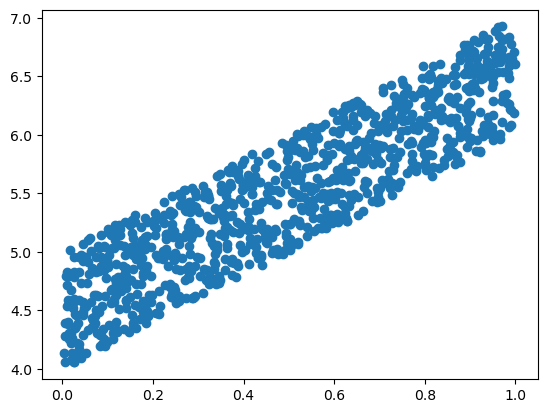

In [33]:
plt.scatter(X, y)
plt.show()

In [34]:
X_0 = add_dummy_feature(X)

A célula acima faz uma cópia do vetor $\mathbf x$, fazendo com que o $\mathbf{x_0}$ seja sempre 1, para que não altere o valor do viés ($\mathbf{\theta_0}$)

# Model

## Using Normal Equation

$$\hat {\boldsymbol{\theta}} = (\mathbf{X^T} \mathbf{X})^{-1} \mathbf{X^T} y$$

In [76]:
class NormalEquation():
    def __init__(self):
        pass
    
    def fit(self, X, y):
        return np.linalg.inv(X.T @ X) @ X.T @ y

    def predict(self, X, y): 
        return X @ self.fit(X_0, y)
    
    def reg_plot(self, X, X_0, y):
        plt.plot(X, self.predict(X_0, y), 'r-')
        plt.plot(X, y, 'b.')
        plt.xlabel(r'$\theta_0$')
        plt.ylabel(r'$\theta_1$')
        plt.show()

In [77]:
normal_model = NormalEquation()

In [78]:
normal_model.fit(X_0, y)

array([[4.49264548],
       [2.02931491]])

In [79]:
y_pred = normal_model.predict(X_0, y)

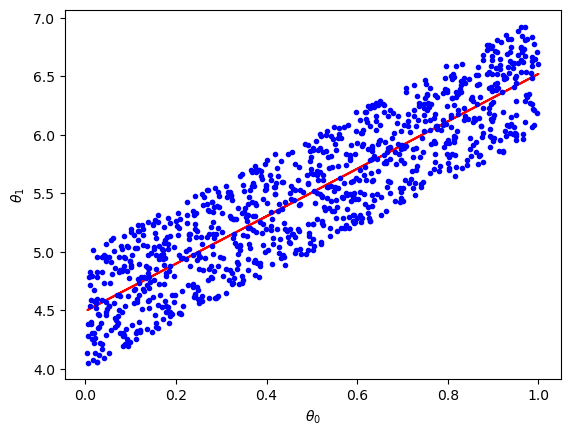

In [80]:
normal_model.reg_plot(X, X_0, y)

## Gradient Descent

$$\frac{\partial}{\partial \theta_j} = 
\frac2m \sum\limits_{i=1}^m \ (\boldsymbol{\theta^T}\mathbf{x}^{(i)} - y^{(i)})  x_j^{(i)}$$

$$\nabla_{\boldsymbol{\theta}} = 
\begin{pmatrix}
    \frac{\partial}{\partial \theta_0} \\
    \frac{\partial}{\partial \theta_1} \\
    \vdots \\
    \frac{\partial}{\partial \theta_n}
\end{pmatrix} 
= \frac{2}{m} \mathbf{X}^{T} (\mathbf{X} \boldsymbol{\theta} - \mathbf{y})$$

$$\boldsymbol{\theta}^{\text{(next step)}} = \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}}$$

### Using Batch Gradient 

In [97]:
class BatchGradient():
    def __init__(self):
        np.random.seed(42)
        self.theta = np.random.rand(2, 1)

    def fit(self, X, y, eta=0.1, n_epochs=1000):
        m = len(X)

        for epoch in range(n_epochs):
            gradients = (2 / m) * X.T @ (X @ self.theta - y)
            self.theta = self.theta - eta * gradients
        return self.theta

    def predict(self, X, y): 
        return X @ self.fit(X_0, y)
    
    def reg_plot(self, X, X_0, y):
        plt.plot(X, self.predict(X_0, y), 'r-')
        plt.plot(X, y, 'b.')
        plt.xlabel(r'$\theta_0$')
        plt.ylabel(r'$\theta_1$')
        plt.show()

In [98]:
batch_model = BatchGradient()

In [99]:
batch_model.fit(X_0, y)

array([[4.49264495],
       [2.02931592]])

In [100]:
y_pred_batch = batch_model.predict(X_0, y)

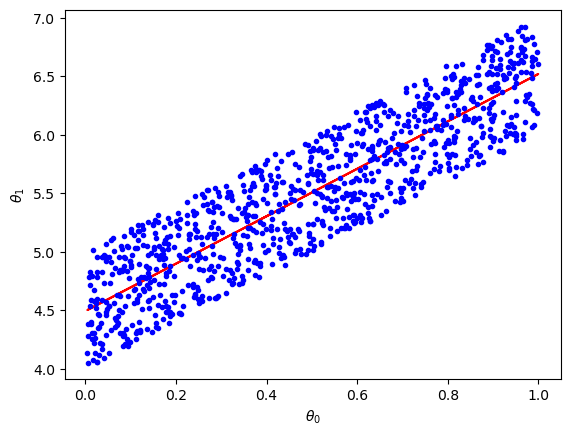

In [101]:
batch_model.reg_plot(X, X_0, y)

### Using Stochastic Gradient

In [111]:
class StochasticGradient():
    def __init__(self):
        np.random.seed(42)
        self.theta = np.random.rand(2, 1)
        self.t0, self.t1 = 5,50
    
    def __learning_schedule(self, t):
        return self.t0 / (t + self.t1)

    def fit(self, X, y, eta=0.01, n_epochs=50):
        m = len(X)

        for epoch in range(n_epochs):
            for iteration in range(m):
                random_index = np.random.randint(m)

                x_i = X[random_index : random_index + 1]
                y_i = y[random_index : random_index + 1]

                gradients =  2 * x_i.T @ (x_i @ self.theta - y_i)
                eta = self.__learning_schedule(epoch * m + iteration)
                self.theta = self.theta - eta * gradients
        return self.theta

    def predict(self, X, y): 
        return X @ self.fit(X_0, y)
    
    def reg_plot(self, X, X_0, y):
        plt.plot(X, self.predict(X_0, y), 'r-')
        plt.plot(X, y, 'b.')
        plt.xlabel(r'$\theta_0$')
        plt.ylabel(r'$\theta_1$')
        plt.show()

In [112]:
stochastic_model = StochasticGradient()

In [113]:
stochastic_model.fit(X_0, y)

array([[4.49105292],
       [2.03462897]])

In [115]:
y_pred_stoch = stochastic_model.predict(X_0, y)

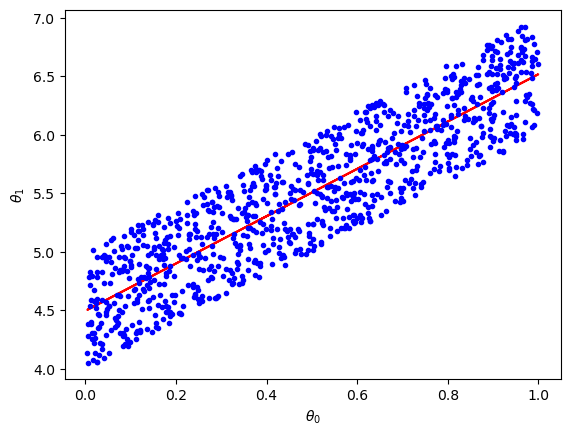

In [116]:
stochastic_model.reg_plot(X, X_0, y)

# Comparando com `scikit-learn`

In [121]:
sk_model = LinearRegression()

In [122]:
sk_model.fit(X_0, y)

LinearRegression()

In [123]:
y_pred_sk = sk_model.predict(X_0)

In [126]:
print(f'Normal Equation: \n Bias: {normal_model.fit(X_0, y)[0]} \t Weight: {normal_model.fit(X_0, y)[1]}')
print(f'Batch Gradient: \n Bias: {batch_model.fit(X_0, y)[0]} \t Weight: {batch_model.fit(X_0, y)[1]}')
print(f'Stochastic Gradient: \n Bias: {stochastic_model.fit(X_0, y)[0]} \t Weight: {stochastic_model.fit(X_0, y)[1]}')
print(f'Scikit-Learn: \n Bias: {sk_model.intercept_} \t Weight: {sk_model.coef_}')

Normal Equation: 
 Bias: [4.49264548] 	 Weight: [2.02931491]
Batch Gradient: 
 Bias: [4.49264548] 	 Weight: [2.02931491]
Stochastic Gradient: 
 Bias: [4.49791404] 	 Weight: [2.02158794]
Scikit-Learn: 
 Bias: [4.49264548] 	 Weight: [[0.         2.02931491]]
